# Running retrievals


There are two ways to run GPROF-NN retrievals:

1. From the command line using the interface provided by the gprof_nn package.
2. Directly from Python using the package's API.


## Command line interface 

The gprof_nn package includes a command-line interface that allows you to run the GPROF-NN retrieval on GPM L1C and GPROF preprocessor files directly from the terminal.

To download a test input file and run the retrieval on it, use the following commands:

````
gprof_nn donwload test_data gmi l1c
gprof_nn retrieve test_data/gmi/1C-R.GPM.GMI.XCAL2016-C.20241008-S051110-E064423.060255.V07B.HDF5
````



## From Python

Alternatively the retrieval can be run from Python using the ``run_retrieval`` function provided by the ``gprof_nn.retrieval`` module. By default, this function will return a list of xarray Datsets containing the retrieval results for all input files.

In [1]:
from gprof_nn.download import download_test_file
from gprof_nn.retrieval import run_retrieval

test_file = download_test_file("gmi", "l1c")
results = run_retrieval(test_file)

[04/02/25 11:34:00] INFO     INFO:gprof_nn.download:Downloading test  file                           ]8;id=813329;file:///home/simon/src/gprof_nn/gprof_nn/download.py\download.py]8;;\:]8;id=607192;file:///home/simon/src/gprof_nn/gprof_nn/download.py#80\80]8;;\
                             1C-R.GPM.GMI.XCAL2016-C.20241008-S051110-E064423.060255.V07B.HDF5 to .                

Output()

[04/02/25 11:34:01] WARNING  WARNING:gprof_nn.retrieval:No preprocessor found on the current       ]8;id=318758;file:///home/simon/src/gprof_nn/gprof_nn/retrieval.py\retrieval.py]8;;\:]8;id=126551;file:///home/simon/src/gprof_nn/gprof_nn/retrieval.py#244\244]8;;\
                             system. Running retrieval without ancillary data.                                     

In [2]:
results[0]

<xarray.Dataset> Size: 23MB
Dimensions:                       (scans: 187, pixels: 221, levels: 28)
Dimensions without coordinates: scans, pixels, levels
Data variables: (12/31)
    pixel_status                  (scans, pixels) float64 331kB -99.0 ... -99.0
    quality_flag                  (scans, pixels) float64 331kB 1.0 1.0 ... 1.0
    scan_time                     (scans) datetime64[ns] 1kB 2024-10-08T06:10...
    longitude                     (scans, pixels) float32 165kB -99.45 ... -8...
    latitude                      (scans, pixels) float32 165kB 32.98 ... 17.47
    total_column_water_vapor      (scans, pixels) float32 165kB -1e+04 ... -1...
    ...                            ...
    ice_water_path                (scans, pixels) float32 165kB 0.0003248 ......
    cloud_water_path              (scans, pixels) float32 165kB 0.01617 ... 0...
    rain_water_content            (scans, pixels, levels) float32 5MB 0.00037...
    snow_water_content            (scans, pixels, levels) float32 5MB 0.0 ......
    cloud_water_content           (scans, pixels, levels) float32 5MB 0.00047...
    latent_heating                (scans, pixels, levels) float32 5MB -0.0004...

### Results

The result dataset contains the retrieval results and all relevant auxiliary data used to calculate the retrieval results. Below we visualize the results, which correspond to an overpass of GMI over hurricane Milton.

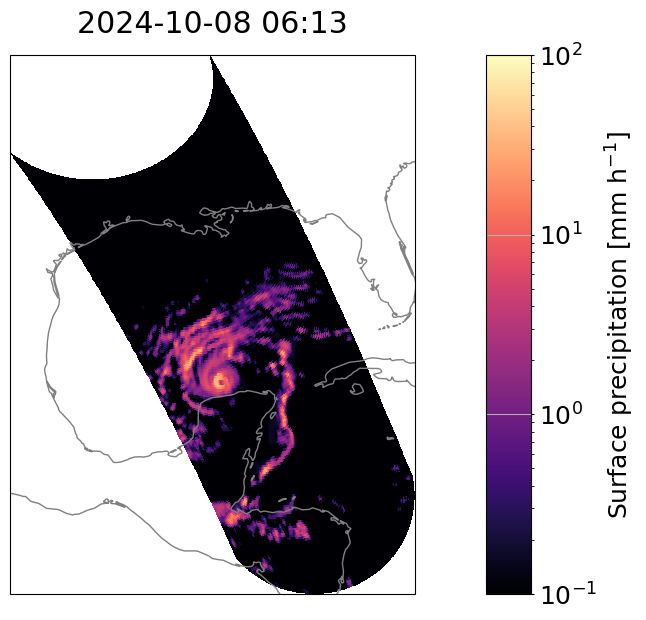

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
from gprof_nn.plotting import set_style, add_ticks

set_style()
fig = plt.figure(figsize=(7, 7))
gs = GridSpec(1, 2, width_ratios=[1.0, 0.1])
crs = ccrs.PlateCarree()


lons = results[0].longitude.data
lats = results[0].latitude.data
surface_precip = results[0].surface_precip
norm = LogNorm(1e-1, 1e2)

date = results[0].scan_time.mean().data.astype("datetime64[s]").item()
ax = fig.add_subplot(gs[0, 0], projection=crs)
m = ax.pcolormesh(lons, lats, surface_precip, norm=norm)
ax.coastlines(color="grey")
ax.set_title(date.strftime("%Y-%m-%d %H:%M"))

cax = fig.add_subplot(gs[0, 1])
plt.colorbar(m, label="Surface precipitation [mm h$^{-1}$]", cax=cax)